# Treinamento e comparação de modelos baseline

Este notebook treina e compara modelos baseline para a predição mensal da quantidade de acidentes em rodovias federais de Santa Catarina, usando o snapshot processado do projeto.

A unidade de previsão é:

```text
municipio | ano | mes -> qtd_acidentes
```

A avaliação usa validação temporal com janelas expansivas, evitando embaralhamento aleatório para respeitar a natureza de série temporal do problema.

## 1. Configuração do ambiente

Modelos testados:

- Baselines simples: média histórica e repetição do último mês observado.
- Modelos lineares: Ridge e Poisson Regressor.
- Modelos não lineares: Random Forest e HistGradientBoosting.

Métricas principais: MAE, RMSE, MAPE sem zeros, WAPE e R².

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PATH = ROOT / 'data' / 'processed' / 'snapshot_acidentes.parquet'
OUTPUT_DIR = ROOT / 'data' / 'processed'

DATA_PATH

PosixPath('/Users/robertdrey/Documents/workspace/development/pgp_machine_learning/data/processed/snapshot_acidentes.parquet')

## 2. Carregamento do snapshot

O arquivo `snapshot_acidentes.parquet` foi criado no notebook anterior agregando os acidentes por município, ano e mês, com meses sem ocorrência preenchidos com zero.

Como o snapshot cria todos os 12 meses de cada ano, filtramos a base de modelagem até o último mês realmente observado em `data/interim/acidentes_SC.parquet`. Isso evita tratar meses futuros ou incompletos como se fossem meses com zero acidentes.


In [2]:
INTERIM_PATH = ROOT / 'data' / 'interim' / 'acidentes_SC.parquet'

def detectar_ultimo_mes_observado(interim_path: Path) -> pd.Timestamp:
    acidentes = pd.read_parquet(interim_path, columns=['data_inversa'])
    acidentes['data_inversa'] = pd.to_datetime(acidentes['data_inversa'])
    return acidentes['data_inversa'].max().to_period('M').to_timestamp()

ULTIMO_MES_OBSERVADO = detectar_ultimo_mes_observado(INTERIM_PATH)

df_snapshot = pd.read_parquet(DATA_PATH)
df_snapshot['data_referencia'] = pd.to_datetime(df_snapshot['data_referencia'])
df_snapshot = df_snapshot.sort_values(['municipio', 'data_referencia']).reset_index(drop=True)

df = df_snapshot[df_snapshot['data_referencia'] <= ULTIMO_MES_OBSERVADO].copy().reset_index(drop=True)

print(f'Linhas no snapshot completo: {df_snapshot.shape[0]:,}')
print(f'Linhas usadas na modelagem: {df.shape[0]:,}')
print(f"Último mês observado nos dados reais: {ULTIMO_MES_OBSERVADO.date()}")
print(f"Período modelado: {df['data_referencia'].min().date()} a {df['data_referencia'].max().date()}")
print(f"Municípios: {df['municipio'].nunique():,}")

display(df.head())
display(df.describe(include='all').T)


Linhas no snapshot completo: 7,620
Linhas usadas na modelagem: 6,731
Último mês observado nos dados reais: 2026-05-01
Período modelado: 2022-01-01 a 2026-05-01
Municípios: 127


,municipio,ano,mes,qtd_acidentes,qtd_mortos,qtd_feridos_graves,qtd_feridos_leves,total_veiculos_envolvidos,data_referencia,lag_acidentes_1m,lag_acidentes_2m,lag_acidentes_12m,media_movel_3m,media_movel_6m,eh_alta_temporada,trimestre,taxa_severidade_acumulada
0,agronomica,2022,1,1,3,1,0,2,2022-01-01,0.000,0.000,0.000,0.000,0.000,1,1,4.000
1,agronomica,2022,2,3,0,0,0,3,2022-02-01,1.000,0.000,0.000,0.500,0.500,1,1,0.000
2,agronomica,2022,3,1,0,1,0,3,2022-03-01,3.000,1.000,0.000,1.333,1.333,0,1,1.000
3,agronomica,2022,4,2,0,1,1,4,2022-04-01,1.000,3.000,0.000,1.667,1.250,0,2,0.500
4,agronomica,2022,5,2,0,1,3,3,2022-05-01,2.000,1.000,0.000,2.000,1.400,0,2,0.500


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
municipio,6731,127,agronomica,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ano,"6,731.000",NaN,NaN,NaN,"2,023.736","2,022.000","2,023.000","2,024.000","2,025.000","2,026.000",1.291
mes,"6,731.000",NaN,NaN,NaN,6.170,1.000,3.000,6.000,9.000,12.000,3.468
qtd_acidentes,"6,731.000",NaN,NaN,NaN,5.274,0.000,1.000,3.000,6.000,82.000,8.818
qtd_mortos,"6,731.000",NaN,NaN,NaN,0.257,0.000,0.000,0.000,0.000,5.000,0.619
qtd_feridos_graves,"6,731.000",NaN,NaN,NaN,1.367,0.000,0.000,0.000,2.000,38.000,2.482
qtd_feridos_leves,"6,731.000",NaN,NaN,NaN,4.594,0.000,0.000,2.000,5.000,73.000,7.858
total_veiculos_envolvidos,"6,731.000",NaN,NaN,NaN,10.419,0.000,1.000,5.000,11.000,179.000,17.763
data_referencia,6731,NaN,NaN,NaN,2024-03-01 13:07:55.471698,2022-01-01 00:00:00,2023-02-01 00:00:00,2024-03-01 00:00:00,2025-04-01 00:00:00,2026-05-01 00:00:00,NaN
lag_acidentes_1m,"6,731.000",NaN,NaN,NaN,5.172,0.000,1.000,2.000,6.000,82.000,8.763


## 3. Definição do alvo e cuidados contra vazamento

A variável-alvo é `qtd_acidentes`.

As colunas de mortos, feridos e veículos envolvidos do mesmo mês não devem entrar diretamente como atributos preditivos, porque esses valores só são conhecidos após a ocorrência dos acidentes. Para manter uma simulação realista, elas serão usadas apenas em versões defasadas ou médias móveis históricas.

In [3]:
TARGET = 'qtd_acidentes'

colunas_vazamento_mes_atual = [
    'qtd_mortos',
    'qtd_feridos_graves',
    'qtd_feridos_leves',
    'total_veiculos_envolvidos',
    'taxa_severidade_acumulada',
]

print('Colunas mantidas fora de X por risco de vazamento do mês atual:')
for col in colunas_vazamento_mes_atual:
    print(f'- {col}')

Colunas mantidas fora de X por risco de vazamento do mês atual:
- qtd_mortos
- qtd_feridos_graves
- qtd_feridos_leves
- total_veiculos_envolvidos
- taxa_severidade_acumulada


## 4. Análise rápida da série-alvo

Antes do treino, vale observar distribuição, sazonalidade e volume agregado por mês. Isso ajuda a interpretar por que baselines com defasagens podem ser competitivos.

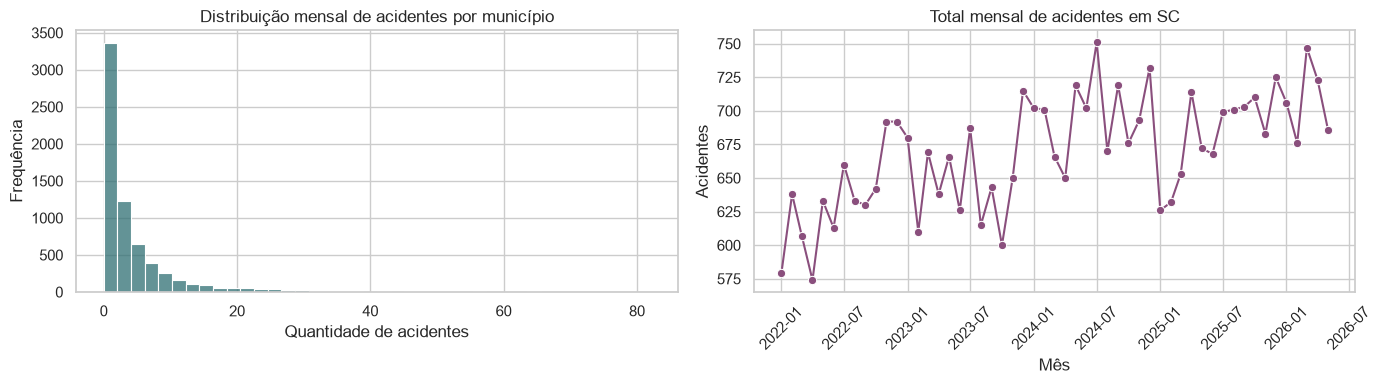

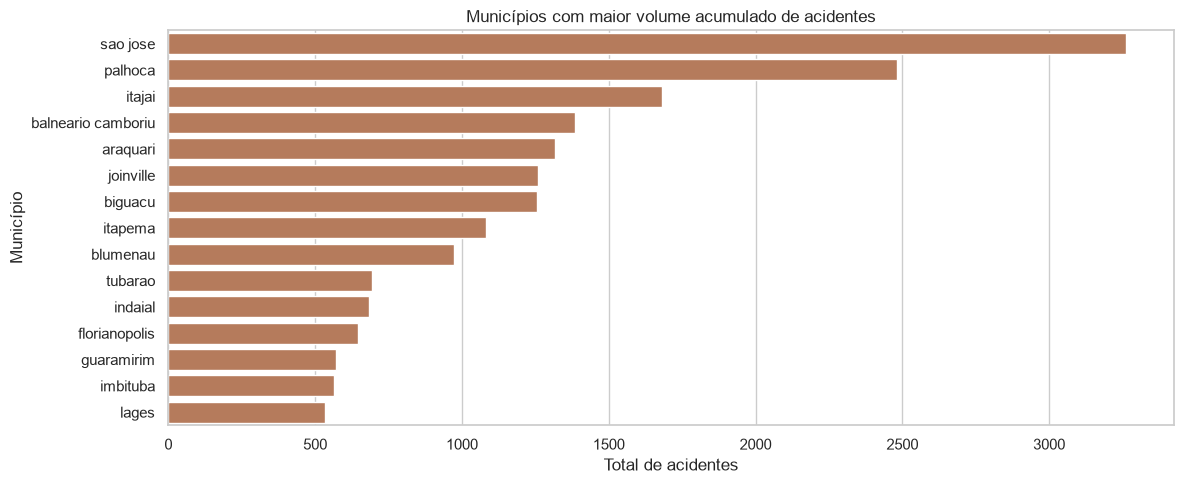

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[TARGET], bins=40, ax=axes[0], color='#2F6F73')
axes[0].set_title('Distribuição mensal de acidentes por município')
axes[0].set_xlabel('Quantidade de acidentes')
axes[0].set_ylabel('Frequência')

serie_mensal = df.groupby('data_referencia', as_index=False)[TARGET].sum()
sns.lineplot(data=serie_mensal, x='data_referencia', y=TARGET, marker='o', ax=axes[1], color='#8A4F7D')
axes[1].set_title('Total mensal de acidentes em SC')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Acidentes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ranking_municipios = (
    df.groupby('municipio', as_index=False)[TARGET]
      .sum()
      .sort_values(TARGET, ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=ranking_municipios, x=TARGET, y='municipio', color='#C4774D')
plt.title('Municípios com maior volume acumulado de acidentes')
plt.xlabel('Total de acidentes')
plt.ylabel('Município')
plt.tight_layout()
plt.show()

## 5. Engenharia de atributos

Serão testadas famílias diferentes de atributos:

- Calendário: ano, mês, trimestre, alta temporada, tendência temporal e codificação cíclica do mês.
- Histórico de acidentes: lags, médias móveis e acumulado anual até o mês anterior.
- Localidade: município via one-hot encoding.
- Histórico de severidade: mortos, feridos e veículos somente em lags e médias móveis, sem usar dados do mês previsto.

In [5]:
def adicionar_atributos_temporais(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy().sort_values(['municipio', 'data_referencia']).reset_index(drop=True)

    data['tempo_idx'] = (data['ano'] - data['ano'].min()) * 12 + data['mes']
    data['mes_sin'] = np.sin(2 * np.pi * data['mes'] / 12)
    data['mes_cos'] = np.cos(2 * np.pi * data['mes'] / 12)

    historicas_mes_atual = [
        'qtd_mortos',
        'qtd_feridos_graves',
        'qtd_feridos_leves',
        'total_veiculos_envolvidos',
    ]

    for col in historicas_mes_atual:
        serie_defasada = data.groupby('municipio')[col].shift(1)
        data[f'{col}_lag_1m'] = serie_defasada.fillna(0)
        data[f'{col}_media_3m'] = (
            serie_defasada.groupby(data['municipio'])
            .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
            .fillna(0)
        )
        data[f'{col}_media_6m'] = (
            serie_defasada.groupby(data['municipio'])
            .transform(lambda s: s.rolling(window=6, min_periods=1).mean())
            .fillna(0)
        )

    data['acidentes_acum_ano_ate_mes_anterior'] = (
        data.groupby(['municipio', 'ano'])[TARGET].cumsum() - data[TARGET]
    )

    data['media_historica_municipio'] = (
        data.groupby('municipio')[TARGET]
        .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
        .fillna(0)
    )

    return data

model_data = adicionar_atributos_temporais(df)

display(model_data.head())

,municipio,ano,mes,qtd_acidentes,qtd_mortos,qtd_feridos_graves,qtd_feridos_leves,total_veiculos_envolvidos,data_referencia,lag_acidentes_1m,lag_acidentes_2m,lag_acidentes_12m,media_movel_3m,media_movel_6m,eh_alta_temporada,trimestre,taxa_severidade_acumulada,tempo_idx,mes_sin,mes_cos,qtd_mortos_lag_1m,qtd_mortos_media_3m,qtd_mortos_media_6m,qtd_feridos_graves_lag_1m,qtd_feridos_graves_media_3m,qtd_feridos_graves_media_6m,qtd_feridos_leves_lag_1m,qtd_feridos_leves_media_3m,qtd_feridos_leves_media_6m,total_veiculos_envolvidos_lag_1m,total_veiculos_envolvidos_media_3m,total_veiculos_envolvidos_media_6m,acidentes_acum_ano_ate_mes_anterior,media_historica_municipio
0,agronomica,2022,1,1,3,1,0,2,2022-01-01,0.000,0.000,0.000,0.000,0.000,1,1,4.000,1,0.500,0.866,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0.000
1,agronomica,2022,2,3,0,0,0,3,2022-02-01,1.000,0.000,0.000,0.500,0.500,1,1,0.000,2,0.866,0.500,3.000,3.000,3.000,1.000,1.000,1.000,0.000,0.000,0.000,2.000,2.000,2.000,1,1.000
2,agronomica,2022,3,1,0,1,0,3,2022-03-01,3.000,1.000,0.000,1.333,1.333,0,1,1.000,3,1.000,0.000,0.000,1.500,1.500,0.000,0.500,0.500,0.000,0.000,0.000,3.000,2.500,2.500,4,2.000
3,agronomica,2022,4,2,0,1,1,4,2022-04-01,1.000,3.000,0.000,1.667,1.250,0,2,0.500,4,0.866,-0.500,0.000,1.000,1.000,1.000,0.667,0.667,0.000,0.000,0.000,3.000,2.667,2.667,5,1.667
4,agronomica,2022,5,2,0,1,3,3,2022-05-01,2.000,1.000,0.000,2.000,1.400,0,2,0.500,5,0.500,-0.866,0.000,0.000,0.750,1.000,0.667,0.750,1.000,0.333,0.250,4.000,3.333,3.000,7,1.750


In [6]:
base_calendar = [
    'ano', 'mes', 'trimestre', 'eh_alta_temporada',
    'tempo_idx', 'mes_sin', 'mes_cos',
]

lag_features = [
    'lag_acidentes_1m', 'lag_acidentes_2m', 'lag_acidentes_12m',
    'media_movel_3m', 'media_movel_6m',
    'acidentes_acum_ano_ate_mes_anterior', 'media_historica_municipio',
]

historico_severidade = [
    col for col in model_data.columns
    if col.endswith('_lag_1m') or col.endswith('_media_3m') or col.endswith('_media_6m')
]

feature_sets = {
    'calendario': {
        'numeric': base_calendar,
        'categorical': [],
    },
    'calendario_lags': {
        'numeric': base_calendar + lag_features,
        'categorical': [],
    },
    'calendario_lags_municipio': {
        'numeric': base_calendar + lag_features,
        'categorical': ['municipio'],
    },
    'completo_historico': {
        'numeric': base_calendar + lag_features + historico_severidade,
        'categorical': ['municipio'],
    },
}

for nome, cfg in feature_sets.items():
    print(f"{nome}: {len(cfg['numeric'])} numéricos + {len(cfg['categorical'])} categóricos")

calendario: 7 numéricos + 0 categóricos
calendario_lags: 14 numéricos + 0 categóricos
calendario_lags_municipio: 14 numéricos + 1 categóricos
completo_historico: 26 numéricos + 1 categóricos


## 6. Separação temporal e métricas

A validação usa backtesting com janela expansiva:

- Treina no passado.
- Testa no ano seguinte.
- Repete até o último ano disponível.

Essa estratégia é mais próxima do uso real do modelo do que um `train_test_split` aleatório.

In [7]:
def montar_folds_temporais(data: pd.DataFrame, ano_inicial_teste: int = 2023):
    anos_teste = sorted(ano for ano in data['ano'].unique() if ano >= ano_inicial_teste)
    folds = []

    for ano_teste in anos_teste:
        idx_treino = data.index[data['ano'] < ano_teste]
        idx_teste = data.index[data['ano'] == ano_teste]
        if len(idx_treino) == 0 or len(idx_teste) == 0:
            continue
        folds.append({
            'ano_teste': int(ano_teste),
            'idx_treino': idx_treino,
            'idx_teste': idx_teste,
            'n_treino': len(idx_treino),
            'n_teste': len(idx_teste),
        })

    return folds

folds = montar_folds_temporais(model_data)
pd.DataFrame([{k: v for k, v in fold.items() if not k.startswith('idx_')} for fold in folds])

,ano_teste,n_treino,n_teste
0,2023,1524,1524
1,2024,3048,1524
2,2025,4572,1524
3,2026,6096,635


In [8]:
def calcular_metricas(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    mask_nonzero = y_true != 0

    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE_%_sem_zeros': (
            np.mean(np.abs((y_true[mask_nonzero] - y_pred[mask_nonzero]) / y_true[mask_nonzero])) * 100
            if mask_nonzero.any()
            else np.nan
        ),
        'WAPE_%': (
            np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100
            if np.sum(y_true) > 0
            else np.nan
        ),
        'R2': r2_score(y_true, y_pred),
    }


def criar_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def criar_pipeline(estimator, numeric_features, categorical_features) -> Pipeline:
    transformers = []

    if numeric_features:
        transformers.append((
            'num',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_features,
        ))

    if categorical_features:
        transformers.append(('cat', criar_one_hot_encoder(), categorical_features))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop',
        sparse_threshold=0,
    )

    return Pipeline(steps=[
        ('preprocessamento', preprocessor),
        ('modelo', clone(estimator)),
    ])

## 7. Treinamento dos modelos

Além dos modelos supervisionados, o notebook calcula dois pontos de referência:

- `DummyMedia`: prevê a média do conjunto de treino.
- `NaiveUltimoMes`: prevê para cada município o mesmo valor observado no mês anterior.

O `NaiveUltimoMes` é especialmente importante porque séries mensais de acidentes costumam ter forte persistência temporal.

In [9]:
modelos = {
    'DummyMedia': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=5.0, random_state=RANDOM_STATE),
    'Poisson': PoissonRegressor(alpha=0.1, max_iter=2_000),
    'RandomForest': RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        loss='squared_error',
        learning_rate=0.06,
        max_iter=300,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    ),
}

resultados = []
predicoes = []

for nome_features, cfg_features in feature_sets.items():
    features = cfg_features['numeric'] + cfg_features['categorical']

    for nome_modelo, estimador in modelos.items():
        for fold in folds:
            treino = model_data.loc[fold['idx_treino']]
            teste = model_data.loc[fold['idx_teste']]

            pipeline = criar_pipeline(
                estimador,
                cfg_features['numeric'],
                cfg_features['categorical'],
            )
            pipeline.fit(treino[features], treino[TARGET])
            y_pred = np.clip(pipeline.predict(teste[features]), 0, None)

            linha = {
                'modelo': nome_modelo,
                'conjunto_atributos': nome_features,
                'ano_teste': fold['ano_teste'],
                'n_treino': fold['n_treino'],
                'n_teste': fold['n_teste'],
            }
            linha.update(calcular_metricas(teste[TARGET], y_pred))
            resultados.append(linha)

            predicoes.append(pd.DataFrame({
                'modelo': nome_modelo,
                'conjunto_atributos': nome_features,
                'ano_teste': fold['ano_teste'],
                'data_referencia': teste['data_referencia'].values,
                'municipio': teste['municipio'].values,
                'y_real': teste[TARGET].values,
                'y_pred': y_pred,
            }))

for fold in folds:
    teste = model_data.loc[fold['idx_teste']]
    y_pred = np.clip(teste['lag_acidentes_1m'].values, 0, None)

    linha = {
        'modelo': 'NaiveUltimoMes',
        'conjunto_atributos': 'lag_1m_direto',
        'ano_teste': fold['ano_teste'],
        'n_treino': fold['n_treino'],
        'n_teste': fold['n_teste'],
    }
    linha.update(calcular_metricas(teste[TARGET], y_pred))
    resultados.append(linha)

    predicoes.append(pd.DataFrame({
        'modelo': 'NaiveUltimoMes',
        'conjunto_atributos': 'lag_1m_direto',
        'ano_teste': fold['ano_teste'],
        'data_referencia': teste['data_referencia'].values,
        'municipio': teste['municipio'].values,
        'y_real': teste[TARGET].values,
        'y_pred': y_pred,
    }))

resultados_df = pd.DataFrame(resultados)
predicoes_df = pd.concat(predicoes, ignore_index=True)

resultados_df.to_csv(OUTPUT_DIR / 'resultados_baseline_modelos.csv', index=False)
predicoes_df.to_csv(OUTPUT_DIR / 'predicoes_baseline_modelos.csv', index=False)

print(f'Treinos avaliados: {len(resultados_df):,}')
display(resultados_df.head())

Treinos avaliados: 84


,modelo,conjunto_atributos,ano_teste,n_treino,n_teste,MAE,RMSE,MAPE_%_sem_zeros,WAPE_%,R2
0,DummyMedia,calendario,2023,1524,1524,4.986,8.591,133.106,97.427,-0.000
1,DummyMedia,calendario,2024,3048,1524,5.175,9.232,132.517,94.106,-0.002
2,DummyMedia,calendario,2025,4572,1524,5.106,8.953,135.152,95.057,-0.000
3,DummyMedia,calendario,2026,6096,635,5.245,9.277,133.412,94.139,-0.001
4,Ridge,calendario,2023,1524,1524,5.322,8.606,154.898,103.995,-0.004


## 8. Comparação geral

A tabela abaixo resume o desempenho médio dos folds temporais. Quanto menor MAE, RMSE, MAPE e WAPE, melhor. Quanto maior R², melhor.

In [10]:
ranking = (
    resultados_df
    .groupby(['modelo', 'conjunto_atributos'], as_index=False)
    .agg(
        MAE_medio=('MAE', 'mean'),
        MAE_std=('MAE', 'std'),
        RMSE_medio=('RMSE', 'mean'),
        MAPE_medio_sem_zeros=('MAPE_%_sem_zeros', 'mean'),
        WAPE_medio=('WAPE_%', 'mean'),
        R2_medio=('R2', 'mean'),
    )
    .sort_values(['MAE_medio', 'RMSE_medio'])
    .reset_index(drop=True)
)

ranking.to_csv(OUTPUT_DIR / 'ranking_baseline_modelos.csv', index=False)
display(ranking)

,modelo,conjunto_atributos,MAE_medio,MAE_std,RMSE_medio,MAPE_medio_sem_zeros,WAPE_medio,R2_medio
0,RandomForest,calendario_lags_municipio,1.756,0.063,2.764,50.935,32.604,0.906
1,RandomForest,completo_historico,1.764,0.077,2.750,51.982,32.732,0.907
2,RandomForest,calendario_lags,1.770,0.074,2.782,52.061,32.855,0.904
3,Ridge,calendario_lags_municipio,1.798,0.113,2.816,52.720,33.449,0.902
4,Ridge,completo_historico,1.805,0.084,2.824,52.710,33.561,0.901
5,Ridge,calendario_lags,1.841,0.161,2.852,54.861,34.255,0.899
6,HistGradientBoosting,completo_historico,1.885,0.103,3.024,53.116,35.031,0.887
7,HistGradientBoosting,calendario_lags,1.896,0.103,3.075,52.823,35.241,0.883
8,HistGradientBoosting,calendario_lags_municipio,1.897,0.090,3.046,53.178,35.247,0.885
9,NaiveUltimoMes,lag_1m_direto,2.215,0.155,3.535,68.353,41.074,0.845


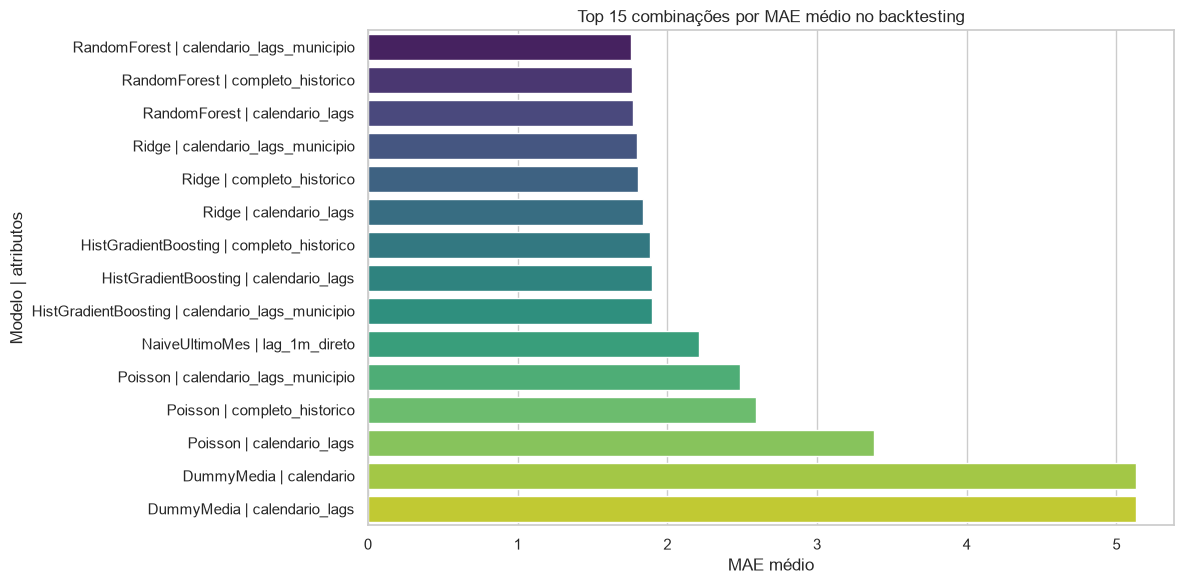

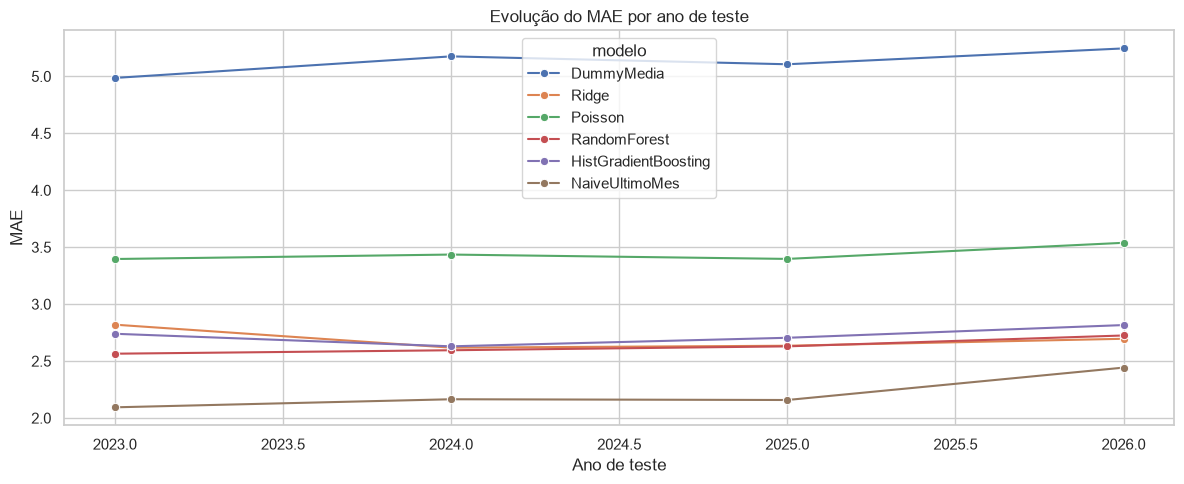

In [11]:
plt.figure(figsize=(12, 6))
plot_data = ranking.head(15).copy()
plot_data['modelo_atributos'] = plot_data['modelo'] + ' | ' + plot_data['conjunto_atributos']
sns.barplot(data=plot_data, x='MAE_medio', y='modelo_atributos', palette='viridis')
plt.title('Top 15 combinações por MAE médio no backtesting')
plt.xlabel('MAE médio')
plt.ylabel('Modelo | atributos')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resultados_df,
    x='ano_teste',
    y='MAE',
    hue='modelo',
    marker='o',
    errorbar=None,
)
plt.title('Evolução do MAE por ano de teste')
plt.xlabel('Ano de teste')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

## 9. Melhor baseline e melhor modelo supervisionado

Como o baseline `NaiveUltimoMes` pode vencer modelos mais complexos, o notebook destaca duas escolhas:

- Melhor resultado geral.
- Melhor modelo supervisionado, excluindo o baseline ingênuo direto.

In [12]:
best_overall = ranking.iloc[0]
best_ml = ranking[ranking['modelo'] != 'NaiveUltimoMes'].iloc[0]

print('Melhor resultado geral:')
display(best_overall.to_frame().T)

print('Melhor modelo supervisionado:')
display(best_ml.to_frame().T)

Melhor resultado geral:


,modelo,conjunto_atributos,MAE_medio,MAE_std,RMSE_medio,MAPE_medio_sem_zeros,WAPE_medio,R2_medio
0,RandomForest,calendario_lags_municipio,1.756,0.063,2.764,50.935,32.604,0.906


Melhor modelo supervisionado:


,modelo,conjunto_atributos,MAE_medio,MAE_std,RMSE_medio,MAPE_medio_sem_zeros,WAPE_medio,R2_medio
0,RandomForest,calendario_lags_municipio,1.756,0.063,2.764,50.935,32.604,0.906


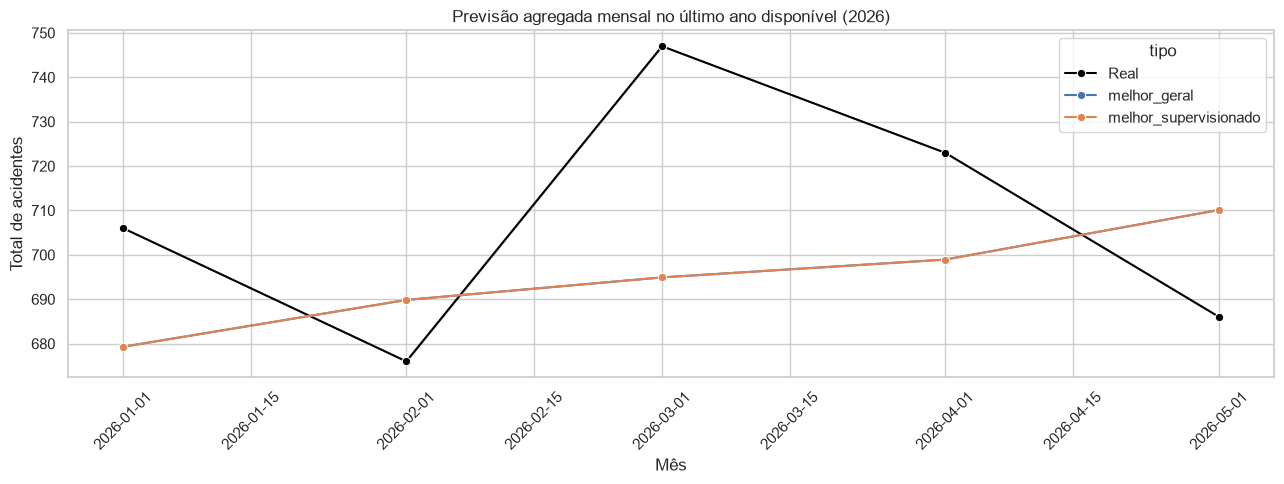

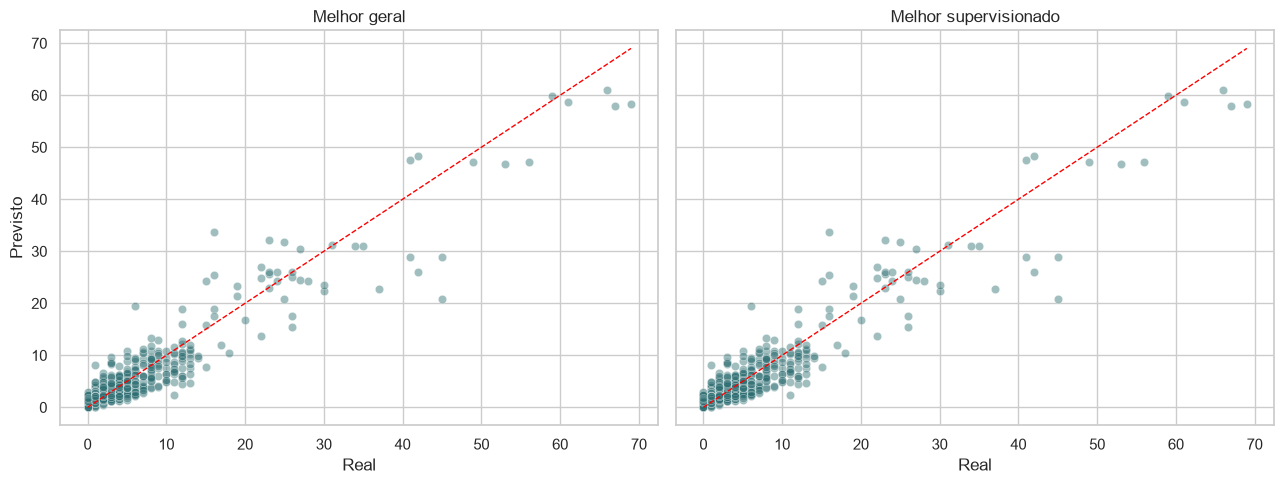

In [13]:
ultimo_ano = int(model_data['ano'].max())
pred_best_overall = predicoes_df[
    (predicoes_df['ano_teste'] == ultimo_ano)
    & (predicoes_df['modelo'] == best_overall['modelo'])
    & (predicoes_df['conjunto_atributos'] == best_overall['conjunto_atributos'])
].copy()

pred_best_ml = predicoes_df[
    (predicoes_df['ano_teste'] == ultimo_ano)
    & (predicoes_df['modelo'] == best_ml['modelo'])
    & (predicoes_df['conjunto_atributos'] == best_ml['conjunto_atributos'])
].copy()

comparacao_agregada = pd.concat([
    pred_best_overall.assign(tipo='melhor_geral'),
    pred_best_ml.assign(tipo='melhor_supervisionado'),
])

serie_comparacao = (
    comparacao_agregada
    .groupby(['tipo', 'data_referencia'], as_index=False)
    .agg(y_real=('y_real', 'sum'), y_pred=('y_pred', 'sum'))
)

plt.figure(figsize=(13, 5))
sns.lineplot(data=serie_comparacao, x='data_referencia', y='y_real', color='black', marker='o', label='Real')
sns.lineplot(data=serie_comparacao, x='data_referencia', y='y_pred', hue='tipo', marker='o')
plt.title(f'Previsão agregada mensal no último ano disponível ({ultimo_ano})')
plt.xlabel('Mês')
plt.ylabel('Total de acidentes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, data_plot, titulo in [
    (axes[0], pred_best_overall, 'Melhor geral'),
    (axes[1], pred_best_ml, 'Melhor supervisionado'),
]:
    sns.scatterplot(data=data_plot, x='y_real', y='y_pred', alpha=0.45, ax=ax, color='#2F6F73')
    max_val = max(data_plot['y_real'].max(), data_plot['y_pred'].max())
    ax.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel('Real')
    ax.set_ylabel('Previsto')
plt.tight_layout()
plt.show()

## 10. Importância dos atributos

A importância abaixo é calculada para o melhor modelo supervisionado no último ano disponível, com `permutation_importance`. Ela indica quanto o erro piora quando uma coluna é embaralhada.

,atributo,importancia_media_MAE,importancia_std
13,media_historica_municipio,0.833,0.049
11,media_movel_6m,0.557,0.033
10,media_movel_3m,0.450,0.036
7,lag_acidentes_1m,0.323,0.026
14,municipio,0.263,0.026
8,lag_acidentes_2m,0.222,0.026
9,lag_acidentes_12m,0.166,0.017
12,acidentes_acum_ano_ate_mes_anterior,0.091,0.010
0,ano,-0.000,0.000
4,tempo_idx,-0.000,0.000


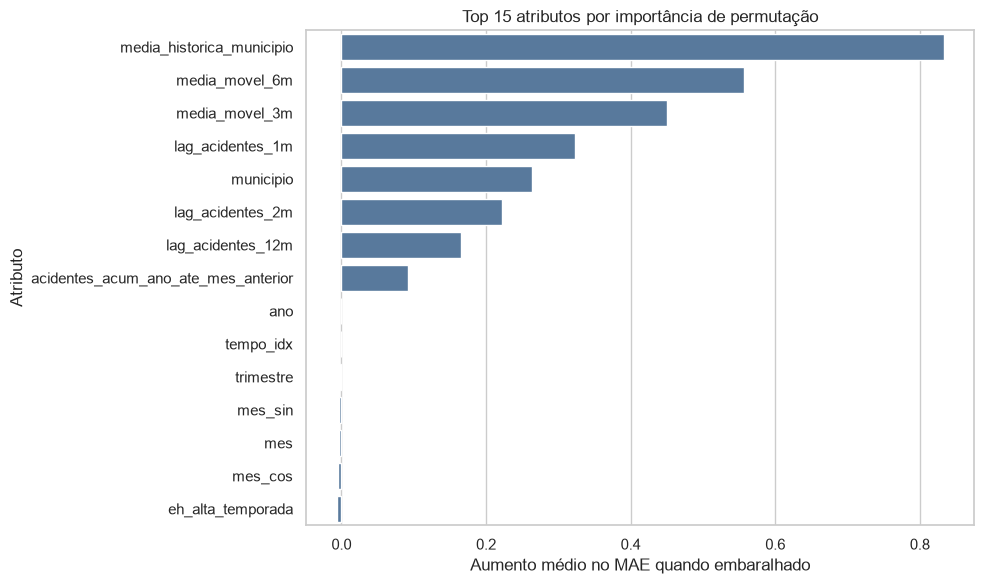

In [14]:
def treinar_modelo_por_linha(linha_ranking):
    nome_modelo = linha_ranking['modelo']
    nome_features = linha_ranking['conjunto_atributos']
    cfg_features = feature_sets[nome_features]
    features = cfg_features['numeric'] + cfg_features['categorical']

    treino = model_data[model_data['ano'] < ultimo_ano]
    teste = model_data[model_data['ano'] == ultimo_ano]

    pipeline = criar_pipeline(modelos[nome_modelo], cfg_features['numeric'], cfg_features['categorical'])
    pipeline.fit(treino[features], treino[TARGET])

    return pipeline, features, treino, teste

modelo_interpretavel, features_interpretaveis, treino_final, teste_final = treinar_modelo_por_linha(best_ml)

perm = permutation_importance(
    modelo_interpretavel,
    teste_final[features_interpretaveis],
    teste_final[TARGET],
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

importancias = (
    pd.DataFrame({
        'atributo': features_interpretaveis,
        'importancia_media_MAE': perm.importances_mean,
        'importancia_std': perm.importances_std,
    })
    .sort_values('importancia_media_MAE', ascending=False)
)

importancias.to_csv(OUTPUT_DIR / 'importancias_baseline_modelo_supervisionado.csv', index=False)
display(importancias.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancias.head(15),
    x='importancia_media_MAE',
    y='atributo',
    color='#4C78A8',
)
plt.title('Top 15 atributos por importância de permutação')
plt.xlabel('Aumento médio no MAE quando embaralhado')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

## 11. Leitura dos resultados

Pontos esperados para análise:

- Se `NaiveUltimoMes` vencer, isso indica forte persistência temporal e define uma régua mínima para versões futuras.
- Se modelos supervisionados ficarem próximos do baseline ingênuo, vale melhorar granularidade espacial, incluir BR/trecho quando disponível e enriquecer calendário com feriados e temporada turística.
- Features do mês atual relacionadas a vítimas e veículos não devem ser usadas diretamente em produção para prever o mesmo mês.
- Para o artigo, MAE e RMSE são métricas principais; WAPE ajuda a interpretar erro percentual em séries com muitos zeros; MAPE deve ser lido apenas sem observações iguais a zero.

In [15]:
print('Arquivos gerados:')
for arquivo in [
    'resultados_baseline_modelos.csv',
    'predicoes_baseline_modelos.csv',
    'ranking_baseline_modelos.csv',
    'importancias_baseline_modelo_supervisionado.csv',
]:
    caminho = OUTPUT_DIR / arquivo
    print(f'- {caminho.relative_to(ROOT)}')

print('\nResumo objetivo:')
print(
    f"Melhor geral: {best_overall['modelo']} com {best_overall['conjunto_atributos']} "
    f"| MAE médio={best_overall['MAE_medio']:.3f}, RMSE médio={best_overall['RMSE_medio']:.3f}, "
    f"WAPE médio={best_overall['WAPE_medio']:.2f}%"
)
print(
    f"Melhor supervisionado: {best_ml['modelo']} com {best_ml['conjunto_atributos']} "
    f"| MAE médio={best_ml['MAE_medio']:.3f}, RMSE médio={best_ml['RMSE_medio']:.3f}, "
    f"WAPE médio={best_ml['WAPE_medio']:.2f}%"
)

Arquivos gerados:
- data/processed/resultados_baseline_modelos.csv
- data/processed/predicoes_baseline_modelos.csv
- data/processed/ranking_baseline_modelos.csv
- data/processed/importancias_baseline_modelo_supervisionado.csv

Resumo objetivo:
Melhor geral: RandomForest com calendario_lags_municipio | MAE médio=1.756, RMSE médio=2.764, WAPE médio=32.60%
Melhor supervisionado: RandomForest com calendario_lags_municipio | MAE médio=1.756, RMSE médio=2.764, WAPE médio=32.60%
